# Propuesta

**Contexto:**

Empresa mexicana enfocada a la fabricación y comercialización de aceites y grasas especializadas para el consumo humano. Mayormente su mercado está segmentado para pequeñas y medianas empresas.

**Objetivo de la empresa:**

La empresa cuida la calidad y el servicio del aceite. Sin embargo, la empresa enfrenta la problemática de querer retener clientes, los cuales, le sean fieles y sigan teniendo un servicio de calidad a pesar de la volatilidad en precios en la materia prima.

**Qué indicador está relacionado al objetivo de la empresa:**
Churn Rate

**Indicadores que estén relacionados con el kpi de la empresa:**
- Customer Satisfaction Scores (CSAT)
- Net Promoter Score (NPS)
- Tiempo del ciclo de cumplimiento del pedido
- Gastos de marketing
- Tiempo de capacitación
- Restricciones gubernamentales a productos que utilizan aceite
- Precios de mercado de productos que lo utilizan
- Escasez de pipas
- Problemas de transporte
- Tiempos de entrega
- Competencia
- Precio de los aranceles
- Competencia de empresas extranjeras
- Falta de personal operativo
- El cambio de divisas
- Falta de flujo
- Tiempos de caducidad
- Precio de materia prima

# Preparación de Datos

In [317]:
#Importamos paqueterias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [318]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [319]:
#Descargamos los datos de Excel de cada rd
df1 = pd.read_excel('/content/drive/MyDrive/Cuarto semestre/Laboratorio/PROYECTO/2022.XLSX', skiprows=4, nrows=3630)
df2 = pd.read_excel('/content/drive/MyDrive/Cuarto semestre/Laboratorio/PROYECTO/2023.xlsx', skiprows=4, nrows=4058)
df3 = pd.read_excel('/content/drive/MyDrive/Cuarto semestre/Laboratorio/PROYECTO/2024.xlsx', skiprows=4, nrows=3488)

In [320]:
#Transformamos nuestros datos
def transformar(df):
    df = df[['Fecha','Cliente','Nombre','Unnamed: 20']] #'Folio'
    df.rename(columns={'Unnamed: 20': 'Total'}, inplace=True)
    #df.rename(columns={'IEPS en M.N.': 'IDAgente'}, inplace=True)
    #df['IDAgente'] = df['IDAgente'].shift(-1)
    df = df.iloc[::2]
    df['Cliente'] = df['Cliente'].astype(int)
    #df['IDAgente'] = df['IDAgente'].astype(int)
    return df

In [321]:
df1 = transformar(df1)
df2 = transformar(df2)
df3 = transformar(df3)

<ipython-input-320-d99fc12d5c4d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'Unnamed: 20': 'Total'}, inplace=True)
<ipython-input-320-d99fc12d5c4d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'Unnamed: 20': 'Total'}, inplace=True)
<ipython-input-320-d99fc12d5c4d>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'Unnamed: 20': 'Total'}, inplace=True)


In [322]:
df_cliente = pd.concat([df1, df2, df3], ignore_index=True)
df_cliente

,Fecha,Cliente,Nombre,Total
0,2022-01-04,40775,PUBLICO EN GENERAL,1600.0
1,2022-01-04,40775,PUBLICO EN GENERAL,1472.0
2,2022-01-04,40775,PUBLICO EN GENERAL,1885.0
3,2022-01-04,41085,LILIAN GONZALEZ,4231.0
4,2022-01-05,41138,OSTY BRAND,52200.0
...,...,...,...,...
5583,2024-10-11,41598,IRAIS BRAVO ALBA,4028.0
5584,2024-10-11,41600,EDUARDO LOPEZ GONZALEZ,2414.0
5585,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0
5586,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0


In [323]:
#Mandamos llamar las variables que necesitaremos
df_dem = pd.read_excel('/content/drive/MyDrive/Cuarto semestre/Laboratorio/PROYECTO/Demograficos.xlsx')
df_giro = pd.read_excel('/content/drive/MyDrive/Cuarto semestre/Laboratorio/PROYECTO/Giro.xlsx')
df_dem = df_dem[['cve_cte','edo_cte','cve_age','cve_zon']]
df_dem.rename(columns={'cve_cte': 'Cliente',
                       'edo_cte': 'Estado',
                       'cve_age': 'Edad_Empresa'}, inplace=True)
df_prov = pd.merge(df_dem, df_giro, on='cve_zon')
df_prov.drop(columns=['cve_zon'], inplace=True)
df_prov

,Cliente,Estado,Edad_Empresa,GIRO
0,1020,JALISCO,22,MOSTRADOR
1,4030,JALISCO,6,MOSTRADOR
2,10110,CIUDAD DE MEXICO,1,PANADERIA
3,10117,GUANAJUATO,7,MOSTRADOR
4,10125,JALISCO,13,MOSTRADOR
...,...,...,...,...
1082,42308,BAJA CALIFORNIA,6,BIMBO
1083,42309,GUANAJUATO,6,MOSTRADOR
1084,42701,JALISCO,7,MOSTRADOR
1085,42702,JALISCO,6,MOSTRADOR


In [324]:
#normalixamos nuestras variables
df_prov['Estado'] = df_prov['Estado'].str.upper()
df_prov['Estado'] = df_prov['Estado'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
df_prov['Estado'] = df_prov['Estado'].replace({
    'DISTRITO FEDERAL': 'DF',
    'JAISCO': 'JALISCO',
    'VERACRUZ DE IGNACIO': 'VERACRUZ',
    'PEBLA': 'PUEBLA',
    'PACHUCA HIDALGO': 'HIDALGO',
    'LA PAZ BAJA CALIFORN': 'BAJA CALIFORNIA SUR',
    'SAN LUIS POTOS': 'SAN LUIS POTOSI'
})

# Reemplazar múltiples valores con el mismo valor
df_prov['Estado'] = df_prov['Estado'].replace(
    ['CD DE MEXICO', 'CD MEXICO', 'CIUDAD DE MEXICO', 'CIUDAD DE MÉXICO', 'CD DE MXICO'
     'EDO DE MEXICO', 'EDO MEXICO', 'ESTADO MEXICO', 'ESTADO DE MEXICO', 'MEXICO','ESTADO DE MXICO',
    'EDO MEX','CIUDAD DE  MEXICO','EDO DE MEXICO','CIUDAD DE MXICO','CD DE MXICO','EDOMEX','ESTADO D MEXICO'], 'CDMX')

df_prov['Estado'] = df_prov['Estado'].replace(
    ['COAHUILA DE ZARAGOZA', 'COAHULA DE ZARAGOZA'], 'COAHUILA')

df_prov['Estado'] = df_prov['Estado'].replace(
    ['BAJA CALIFORNI', 'BC'], 'BAJA CALIFORNIA')

df_prov['Estado'] = df_prov['Estado'].replace(
    ['PACHUCA HIDALGO', 'HIDLGO'], 'HIDALGO')

df_prov['Estado'] = df_prov['Estado'].replace(
    ['MONTERREY NL', 'L','LEON'], 'NUEVO LEON')

df_prov['Estado'] = df_prov['Estado'].replace(
    ['AGUSCALIENTES', 'A','AGUAS CALIENTES'], 'AGUASCALIENTES')

df_prov['Estado'] = df_prov['Estado'].replace(
    ['MICHOACAN DE OCAMP', 'MICHOACAN DE OCAMPO', 'MICHOACÁN','MICHOACN'], 'MICHOACAN')

print(df_prov['Estado'].unique())

['JALISCO' 'CDMX' 'GUANAJUATO' 'NUEVO LEON' 'MICHOACAN' 'MONTERREY'
 'NAYARIT' 'PUEBLA' 'QUERETARO' 'DF' 'SINALOA' 'CHIHUAHUA'
 'AGUASCALIENTES' 'SONORA' 'HIDALGO' 'TAMAULIPAS' 'BAJA CALIFORNIA SUR'
 'BAJA CALIFORNIA' '' 'TOLUCA' 'COAHUILA' 'MORELOS' 'ZACATECAS' 'YUCATAN'
 'VERACRUZ' 'OAXACA' 'QUINTANA ROO' 'DURANGO' 'COLIMA' 'SAN LUIS POTOSI'
 'GUERRERO' 'COLOMBIA' 'HERMOSILLO' 'CHICHUAHUA' 'CHIAPAS' 'CAMPECHE'
 'MORELIA' 'VALLE DEL CAUCA' 'ALAJUELA' 'TLAXCALA' 'TABASCO' 'BOGOTA'
 'CULIACAN']


In [325]:
#filtramos los datos
df = pd.merge(df_cliente, df_prov, on='Cliente')
df = df[~df.isin(['.', '']).any(axis=1)].reset_index()
df = df.drop(columns=['index'])
df

,Fecha,Cliente,Nombre,Total,Estado,Edad_Empresa,GIRO
0,2022-01-04,41085,LILIAN GONZALEZ,4231.0,CDMX,7,PANADERIA
1,2022-01-05,41138,OSTY BRAND,52200.0,JALISCO,1,MOSTRADOR
2,2022-01-05,40809,VASERCO,54900.0,JALISCO,7,MOSTRADOR
3,2022-01-05,41147,XITLALLI VERONICA SÁNCHEZ,4828.0,JALISCO,7,MOSTRADOR
4,2022-01-05,40770,NB FOODS,50400.0,JALISCO,7,MOSTRADOR
...,...,...,...,...,...,...,...
4765,2024-10-11,41598,IRAIS BRAVO ALBA,4028.0,GUANAJUATO,6,MOSTRADOR
4766,2024-10-11,41600,EDUARDO LOPEZ GONZALEZ,2414.0,TAMAULIPAS,6,BIMBO
4767,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0,JALISCO,6,MOSTRADOR
4768,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0,JALISCO,6,MOSTRADOR


In [326]:
#creamos las regiones que clasificaran nuestros clusters
regiones_mexico = {
    # Norte
    'BAJA CALIFORNIA': 'Norte', 'BAJA CALIFORNIA SUR': 'Norte', 'CHIHUAHUA': 'Norte',
    'COAHUILA': 'Norte', 'DURANGO': 'Norte', 'NUEVO LEON': 'Norte', 'SONORA': 'Norte',
    'TAMAULIPAS': 'Norte', 'SINALOA': 'Norte',
    # Sur
    'CHIAPAS': 'Sur', 'GUERRERO': 'Sur', 'OAXACA': 'Sur',
    'CAMPECHE': 'Sur', 'TABASCO': 'Sur', 'QUINTANA ROO': 'Sur', 'YUCATAN': 'Sur',
    # Oeste
    'JALISCO': 'Oeste', 'NAYARIT': 'Oeste', 'COLIMA': 'Oeste', 'MICHOACAN': 'Oeste',
    'ZACATECAS': 'Oeste', 'AGUASCALIENTES': 'Oeste',
    # Este
    'PUEBLA': 'Este', 'VERACRUZ': 'Este', 'HIDALGO': 'Este', 'TLAXCALA': 'Este',
    'QUERETARO': 'Este', 'SAN LUIS POTOSI': 'Este',
    # Centro
    'CDMX': 'Centro', 'DF': 'Centro', 'MORELOS': 'Centro'
}
# Función para categorizar los estados
def categorizar_estado(estado):
    return regiones_mexico.get(estado, 'Foráneo')

# Crear la nueva columna con las regiones
df['Region_MXN'] = df['Estado'].apply(categorizar_estado)
df.head()

,Fecha,Cliente,Nombre,Total,Estado,Edad_Empresa,GIRO,Region_MXN
0,2022-01-04,41085,LILIAN GONZALEZ,4231.0,CDMX,7,PANADERIA,Centro
1,2022-01-05,41138,OSTY BRAND,52200.0,JALISCO,1,MOSTRADOR,Oeste
2,2022-01-05,40809,VASERCO,54900.0,JALISCO,7,MOSTRADOR,Oeste
3,2022-01-05,41147,XITLALLI VERONICA SÁNCHEZ,4828.0,JALISCO,7,MOSTRADOR,Oeste
4,2022-01-05,40770,NB FOODS,50400.0,JALISCO,7,MOSTRADOR,Oeste


In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4770 entries, 0 to 4769
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Fecha         4770 non-null   datetime64[ns]
 1   Cliente       4770 non-null   int64         
 2   Nombre        4770 non-null   object        
 3   Total         4760 non-null   float64       
 4   Estado        4770 non-null   object        
 5   Edad_Empresa  4770 non-null   int64         
 6   GIRO          4770 non-null   object        
 7   Region_MXN    4770 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 298.2+ KB


# Clusters

In [328]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

In [329]:
df_cluster = df.drop(['Cliente', 'Fecha', 'Nombre','Total'], axis=1)
df_cluster = df_cluster.drop_duplicates()
df_cluster.head()

,Estado,Edad_Empresa,GIRO,Region_MXN
0,CDMX,7,PANADERIA,Centro
1,JALISCO,1,MOSTRADOR,Oeste
2,JALISCO,7,MOSTRADOR,Oeste
5,NUEVO LEON,6,BIMBO,Norte
8,JALISCO,6,MOSTRADOR,Oeste


In [330]:
#Identificamos nuestras numerical y categorical features
numerical_features = ['Edad_Empresa']
categorical_features = ['Region_MXN','GIRO']

In [331]:
#Hacemos el Dummies
encoded_features = pd.get_dummies(df_cluster[categorical_features],
    columns = categorical_features, drop_first=False)
encoded_features.head()

,Region_MXN_Centro,Region_MXN_Este,Region_MXN_Foráneo,Region_MXN_Norte,Region_MXN_Oeste,Region_MXN_Sur,GIRO_BIMBO,GIRO_COBERTURA DE CHOCOLATE,GIRO_DISTRIBUIDORES,GIRO_FARMACEUTICOS,GIRO_JABONEROS,GIRO_MANTEQUILLAS,GIRO_MOSTRADOR,GIRO_PANADERIA,GIRO_SABORIZANTES
0,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
5,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
8,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False


In [332]:
data_to_model_std = StandardScaler().fit_transform(df[numerical_features])
data_to_model_df = pd.DataFrame(data_to_model_std, columns=numerical_features).reset_index()
encoded_features_df = encoded_features.reset_index()
data_to_model = data_to_model_df.merge(encoded_features_df, on='index')
data_to_model = data_to_model.drop(['index'], axis = 1)
data_to_model

,Edad_Empresa,Region_MXN_Centro,Region_MXN_Este,Region_MXN_Foráneo,Region_MXN_Norte,Region_MXN_Oeste,Region_MXN_Sur,GIRO_BIMBO,GIRO_COBERTURA DE CHOCOLATE,GIRO_DISTRIBUIDORES,GIRO_FARMACEUTICOS,GIRO_JABONEROS,GIRO_MANTEQUILLAS,GIRO_MOSTRADOR,GIRO_PANADERIA,GIRO_SABORIZANTES
0,-0.382565,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,-1.724189,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2,-0.382565,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
3,-0.606169,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
4,-0.606169,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,0.959060,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
144,1.182664,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
145,-0.382565,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
146,0.959060,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False


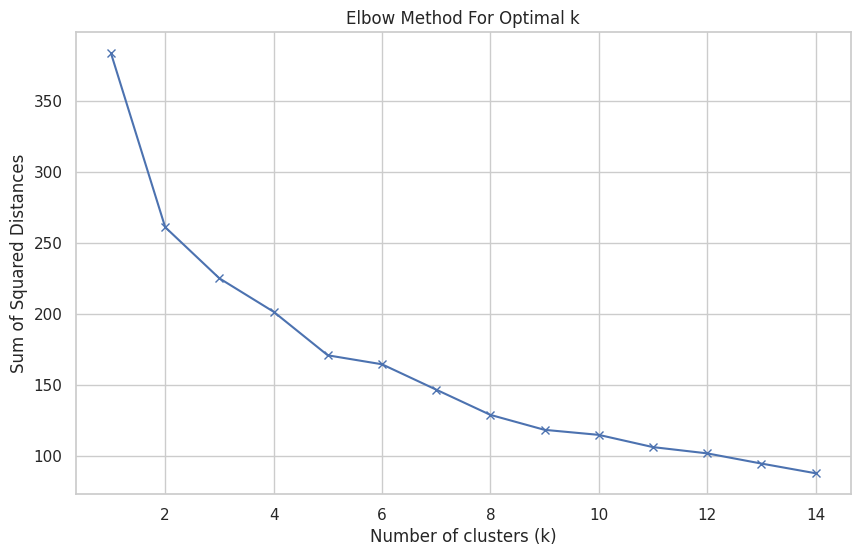

In [333]:
# Determinar el número óptimo de clusters usando el método del codo
sum_of_squared_distances = []
K = range(1, 15)  # Ajuste el rango según sea necesario
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km = km.fit(data_to_model)
    sum_of_squared_distances.append(km.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, sum_of_squared_distances, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [334]:
#realizamos la clusterización
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(data_to_model)

In [335]:
df_cluster['cluster']=labels

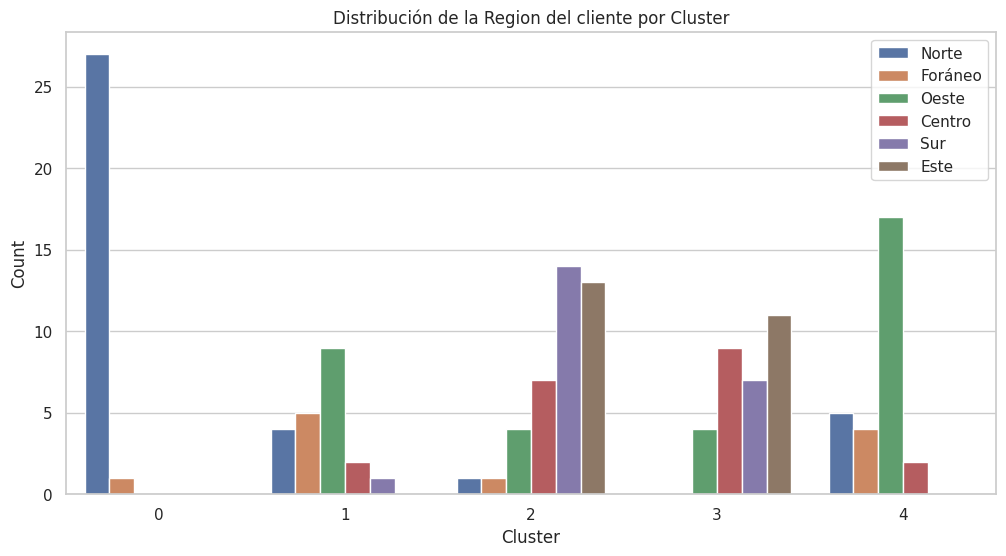

In [336]:
#Graficamos los clusters
sns.countplot(x='cluster', hue='Region_MXN', data=df_cluster)
plt.title('Distribución de la Region del cliente por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend()
plt.show()

# Churn Rate

In [337]:
#Creamos el churn rate
df_grouped = df.groupby(['Cliente', 'Fecha', 'Region_MXN'])['Total'].sum().reset_index()
df_grouped.head()

,Cliente,Fecha,Region_MXN,Total
0,1020,2022-01-21,Oeste,1300.00
1,1020,2022-09-06,Oeste,4265.78
2,1020,2022-10-31,Oeste,1421.92
3,1020,2022-11-03,Oeste,1421.93
4,1020,2022-11-14,Oeste,5687.67


In [338]:
df_grouped = df_grouped[(df_grouped['Total']>0)].dropna()
df_grouped = df_grouped.sort_values(['Cliente','Fecha'], ascending=True)
df_grouped.head()

,Cliente,Fecha,Region_MXN,Total
0,1020,2022-01-21,Oeste,1300.00
1,1020,2022-09-06,Oeste,4265.78
2,1020,2022-10-31,Oeste,1421.92
3,1020,2022-11-03,Oeste,1421.93
4,1020,2022-11-14,Oeste,5687.67


In [339]:
#identificamos los days between purchase
df_grouped['DaysBetweenPurchase'] = df_grouped.groupby('Cliente')['Fecha'].diff().dt.days
df_grouped.head()

,Cliente,Fecha,Region_MXN,Total,DaysBetweenPurchase
0,1020,2022-01-21,Oeste,1300.00,NaN
1,1020,2022-09-06,Oeste,4265.78,228.0
2,1020,2022-10-31,Oeste,1421.92,55.0
3,1020,2022-11-03,Oeste,1421.93,3.0
4,1020,2022-11-14,Oeste,5687.67,11.0


In [340]:
#Definimos el quantil que vamos a utilizar
df_grouped['DaysBetweenPurchase'].quantile([0.8,0.9,0.95])

,DaysBetweenPurchase
0.80,57.0
0.90,101.0
0.95,178.4


In [341]:
#Sacamos el threshold general
general_threshold = df_grouped['DaysBetweenPurchase'].quantile(0.9)
general_threshold

101.0

In [342]:
#Agregamos los datos
threshold_per_country = df_grouped.groupby('Region_MXN')['DaysBetweenPurchase'].agg(
    percentile_90=lambda x: x.quantile(0.90),
    transaction_count='count'
).reset_index()
threshold_per_country

,Region_MXN,percentile_90,transaction_count
0,Centro,120.0,561
1,Este,140.0,224
2,Foráneo,99.8,63
3,Norte,158.8,540
4,Oeste,78.0,2199
5,Sur,192.5,66


In [343]:
#Incluimos el threshold calculado en la tabla
threshold_per_country['threshold'] = threshold_per_country.apply(
    lambda row: general_threshold if row['transaction_count'] < 30 else row['percentile_90'],
    axis=1
)

threshold_per_country

,Region_MXN,percentile_90,transaction_count,threshold
0,Centro,120.0,561,120.0
1,Este,140.0,224,140.0
2,Foráneo,99.8,63,99.8
3,Norte,158.8,540,158.8
4,Oeste,78.0,2199,78.0
5,Sur,192.5,66,192.5


In [344]:
last_invoice_date_per_customer = df_grouped.groupby(['Region_MXN','Cliente'])['Fecha'].max().reset_index().rename(columns={'Fecha': 'LastInvoiceDate'})

last_invoice_date_per_customer.head()

,Region_MXN,Cliente,LastInvoiceDate
0,Centro,10110,2024-04-18
1,Centro,10207,2024-10-09
2,Centro,10910,2024-09-17
3,Centro,40204,2024-04-30
4,Centro,40322,2024-10-07


In [345]:
customers = last_invoice_date_per_customer.merge(threshold_per_country, on='Region_MXN')
customers.head()

,Region_MXN,Cliente,LastInvoiceDate,percentile_90,transaction_count,threshold
0,Centro,10110,2024-04-18,120.0,561,120.0
1,Centro,10207,2024-10-09,120.0,561,120.0
2,Centro,10910,2024-09-17,120.0,561,120.0
3,Centro,40204,2024-04-30,120.0,561,120.0
4,Centro,40322,2024-10-07,120.0,561,120.0


In [346]:
snapshot_date = df_grouped['Fecha'].max()
snapshot_date

Timestamp('2024-10-11 00:00:00')

In [347]:
customers['inactivity_days'] = (snapshot_date - customers['LastInvoiceDate']).dt.days
customers['churned'] = (customers['inactivity_days'] > customers['threshold']).astype('int')

customers.head()

,Region_MXN,Cliente,LastInvoiceDate,percentile_90,transaction_count,threshold,inactivity_days,churned
0,Centro,10110,2024-04-18,120.0,561,120.0,176,1
1,Centro,10207,2024-10-09,120.0,561,120.0,2,0
2,Centro,10910,2024-09-17,120.0,561,120.0,24,0
3,Centro,40204,2024-04-30,120.0,561,120.0,164,1
4,Centro,40322,2024-10-07,120.0,561,120.0,4,0


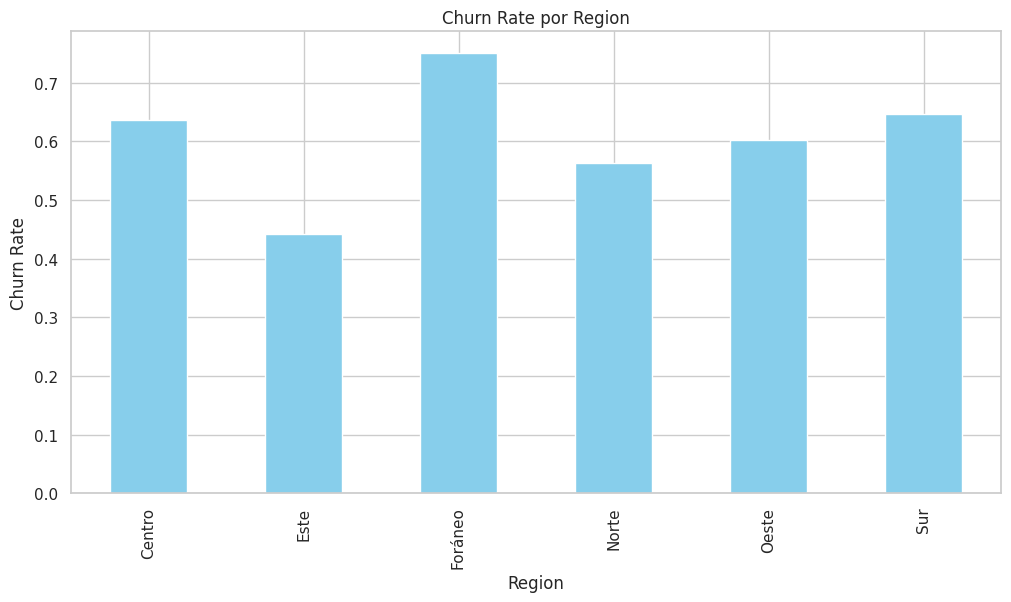

In [348]:
#Graficamos
customers.groupby('Region_MXN')['churned'].mean().plot(kind='bar', color='skyblue')
plt.title('Churn Rate por Region')
plt.xlabel('Region')
plt.ylabel('Churn Rate')
plt.show()

# LTV

In [349]:
#Datoos que usamos para el LTV
df_min_fecha = df.groupby('Cliente')['Fecha'].min().reset_index()
df_min_fecha.rename(columns={'Fecha': 'Cohort'}, inplace=True)
df_ltv = pd.merge(df, df_min_fecha, on='Cliente')
df_ltv

,Fecha,Cliente,Nombre,Total,Estado,Edad_Empresa,GIRO,Region_MXN,Cohort
0,2022-01-04,41085,LILIAN GONZALEZ,4231.0,CDMX,7,PANADERIA,Centro,2022-01-04
1,2022-01-05,41138,OSTY BRAND,52200.0,JALISCO,1,MOSTRADOR,Oeste,2022-01-05
2,2022-01-05,40809,VASERCO,54900.0,JALISCO,7,MOSTRADOR,Oeste,2022-01-05
3,2022-01-05,41147,XITLALLI VERONICA SÁNCHEZ,4828.0,JALISCO,7,MOSTRADOR,Oeste,2022-01-05
4,2022-01-05,40770,NB FOODS,50400.0,JALISCO,7,MOSTRADOR,Oeste,2022-01-05
...,...,...,...,...,...,...,...,...,...
4765,2024-10-11,41598,IRAIS BRAVO ALBA,4028.0,GUANAJUATO,6,MOSTRADOR,Foráneo,2024-10-11
4766,2024-10-11,41600,EDUARDO LOPEZ GONZALEZ,2414.0,TAMAULIPAS,6,BIMBO,Norte,2024-10-11
4767,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0,JALISCO,6,MOSTRADOR,Oeste,2024-03-14
4768,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0,JALISCO,6,MOSTRADOR,Oeste,2024-03-14


In [350]:
#Calculamos el LTV
df_ltv['customer_tenure'] = (snapshot_date.year - df_ltv['Cohort'].dt.year)*12 + (
    snapshot_date.month - df_ltv['Cohort'].dt.month)
df_ltv.head()

,Fecha,Cliente,Nombre,Total,Estado,Edad_Empresa,GIRO,Region_MXN,Cohort,customer_tenure
0,2022-01-04,41085,LILIAN GONZALEZ,4231.0,CDMX,7,PANADERIA,Centro,2022-01-04,33
1,2022-01-05,41138,OSTY BRAND,52200.0,JALISCO,1,MOSTRADOR,Oeste,2022-01-05,33
2,2022-01-05,40809,VASERCO,54900.0,JALISCO,7,MOSTRADOR,Oeste,2022-01-05,33
3,2022-01-05,41147,XITLALLI VERONICA SÁNCHEZ,4828.0,JALISCO,7,MOSTRADOR,Oeste,2022-01-05,33
4,2022-01-05,40770,NB FOODS,50400.0,JALISCO,7,MOSTRADOR,Oeste,2022-01-05,33


In [351]:
#LTV en el customer tenure on transacctions
df_ltv['customer_tenure_on_transaction'] = (
    df_ltv['Fecha'].dt.year - df_ltv['Cohort'].dt.year)*12 + (
    df_ltv['Fecha'].dt.month - df_ltv['Cohort'].dt.month)

df_ltv['customer_tenure_on_transaction']

,customer_tenure_on_transaction
0,0
1,0
2,0
3,0
4,0
...,...
4765,0
4766,0
4767,7
4768,7


In [352]:
cltv_24_months = df_ltv[
    (df_ltv['customer_tenure'] > 24) &
    (df_ltv['customer_tenure_on_transaction'] <= 24)
].groupby('Cliente')['Total'].sum().reset_index()

cltv_24_months.rename(columns={'Total': 'LTV_24'}, inplace=True)

cltv_24_months

,Cliente,LTV_24
0,1020,58271.65
1,10110,1663931.60
2,10715,824150.00
3,10716,1316650.70
4,10720,12595.00
...,...,...
246,42108,3162.00
247,42201,17960.00
248,42309,258552.00
249,42701,3374.00


In [353]:
#Incluimos LTV en la tabla
df = pd.merge(df, cltv_24_months, on='Cliente')
df

,Fecha,Cliente,Nombre,Total,Estado,Edad_Empresa,GIRO,Region_MXN,LTV_24
0,2022-01-04,41085,LILIAN GONZALEZ,4231.0,CDMX,7,PANADERIA,Centro,33199.00
1,2022-01-05,41138,OSTY BRAND,52200.0,JALISCO,1,MOSTRADOR,Oeste,7698080.34
2,2022-01-05,40809,VASERCO,54900.0,JALISCO,7,MOSTRADOR,Oeste,9805358.50
3,2022-01-05,41147,XITLALLI VERONICA SÁNCHEZ,4828.0,JALISCO,7,MOSTRADOR,Oeste,35503.00
4,2022-01-05,40770,NB FOODS,50400.0,JALISCO,7,MOSTRADOR,Oeste,3595185.00
...,...,...,...,...,...,...,...,...,...
3373,2024-10-09,40809,VASERCO,38430.0,JALISCO,7,MOSTRADOR,Oeste,9805358.50
3374,2024-10-09,41202,JOSE JORGE GARCIA SANCHEZ,18866.0,JALISCO,7,MOSTRADOR,Oeste,432429.00
3375,2024-10-09,40879,SMAT MEXICO,7105.0,CDMX,22,PANADERIA,Centro,19674.30
3376,2024-10-10,40819,VERONICA SANDOVAL HERNANDEZ,4692.0,JALISCO,22,MOSTRADOR,Oeste,188292.00


# Predicción  de LTV a 24 meses

In [354]:
df_model = df.drop(["Fecha", "Total"], axis=1)
df_model = df_model.drop_duplicates()
df_model

,Cliente,Nombre,Estado,Edad_Empresa,GIRO,Region_MXN,LTV_24
0,41085,LILIAN GONZALEZ,CDMX,7,PANADERIA,Centro,33199.00
1,41138,OSTY BRAND,JALISCO,1,MOSTRADOR,Oeste,7698080.34
2,40809,VASERCO,JALISCO,7,MOSTRADOR,Oeste,9805358.50
3,41147,XITLALLI VERONICA SÁNCHEZ,JALISCO,7,MOSTRADOR,Oeste,35503.00
4,40770,NB FOODS,JALISCO,7,MOSTRADOR,Oeste,3595185.00
...,...,...,...,...,...,...,...
971,41257,SANARA TULUM,QUINTANA ROO,6,PANADERIA,Sur,2153.00
974,41258,PRODUCTOS HELADOS MILKY MICH,CDMX,13,PANADERIA,Centro,4857480.00
991,40986,EMILIO SOLACHE ABONCE,MICHOACAN,7,PANADERIA,Oeste,5618.50
999,40943,EDELBERTO TORRES HERNANDEZ,JALISCO,7,MOSTRADOR,Oeste,785006.00


# Regresión Lineal

In [355]:
#Instalamos packeteria
import statsmodels.api as sm

In [356]:
categorical_features = ['Region_MXN', 'GIRO']
numerical_features = ['Edad_Empresa', 'LTV_24']

data_encoded = pd.get_dummies(df_model[['Cliente']+categorical_features],
                              columns=categorical_features,
                              drop_first=False)

df_data_with_encoded = df_model[['Cliente']+numerical_features].merge(
    data_encoded, on='Cliente')

df_data_with_encoded = df_data_with_encoded.astype({
    col: 'int' for col in df_data_with_encoded.select_dtypes('bool').columns})

df_data_with_encoded.columns = [col.replace(' ', '') for col in df_data_with_encoded.columns]

df_data_with_encoded.head()

,Cliente,Edad_Empresa,LTV_24,Region_MXN_Centro,Region_MXN_Este,Region_MXN_Foráneo,Region_MXN_Norte,Region_MXN_Oeste,Region_MXN_Sur,GIRO_BIMBO,GIRO_COBERTURADECHOCOLATE,GIRO_MANTEQUILLAS,GIRO_MOSTRADOR,GIRO_PANADERIA,GIRO_SABORIZANTES
0,41085,7,33199.00,1,0,0,0,0,0,0,0,0,0,1,0
1,41138,1,7698080.34,0,0,0,0,1,0,0,0,0,1,0,0
2,40809,7,9805358.50,0,0,0,0,1,0,0,0,0,1,0,0
3,41147,7,35503.00,0,0,0,0,1,0,0,0,0,1,0,0
4,40770,7,3595185.00,0,0,0,0,1,0,0,0,0,1,0,0


In [357]:
# Modelo de regresion con todas las variables
df_to_model =df_data_with_encoded[['Edad_Empresa','Region_MXN_Centro','Region_MXN_Este','Region_MXN_Foráneo','Region_MXN_Norte','Region_MXN_Oeste','Region_MXN_Sur','GIRO_BIMBO','GIRO_COBERTURADECHOCOLATE','GIRO_MANTEQUILLAS','GIRO_MOSTRADOR','GIRO_PANADERIA','GIRO_SABORIZANTES','LTV_24']]

#lista con variables fijas x, variable que vas a predecir y
x = ['Edad_Empresa','Region_MXN_Centro','Region_MXN_Este','Region_MXN_Foráneo','Region_MXN_Norte','Region_MXN_Oeste','Region_MXN_Sur','GIRO_BIMBO','GIRO_COBERTURADECHOCOLATE','GIRO_MANTEQUILLAS','GIRO_MOSTRADOR','GIRO_PANADERIA','GIRO_SABORIZANTES']
y = ['LTV_24']

X = sm.add_constant(df_to_model[x])

model = sm.OLS(df_to_model[y],X)
results = model.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                 LTV_24   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.032
Date:                Tue, 26 Nov 2024   Prob (F-statistic):              0.419
Time:                        22:00:22   Log-Likelihood:                -3902.9
No. Observations:                 251   AIC:                             7830.
Df Residuals:                     239   BIC:                             7872.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [358]:
# Modelo de regresion con variables de p-value menor a 0.05
df_to_model =df_data_with_encoded[['Edad_Empresa','Region_MXN_Centro','Region_MXN_Este','Region_MXN_Foráneo','Region_MXN_Norte','Region_MXN_Oeste','Region_MXN_Sur','GIRO_BIMBO','GIRO_COBERTURADECHOCOLATE','GIRO_MANTEQUILLAS','GIRO_MOSTRADOR','GIRO_PANADERIA','GIRO_SABORIZANTES', 'Edad_Empresa','LTV_24']]

#lista con variables fijas x, variable que vas a predecir y
x = ['GIRO_MANTEQUILLAS']
y = ['LTV_24']

X = sm.add_constant(df_to_model[x])

model = sm.OLS(df_to_model[y],X)
results = model.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                 LTV_24   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     8.448
Date:                Tue, 26 Nov 2024   Prob (F-statistic):            0.00398
Time:                        22:00:22   Log-Likelihood:                -3904.5
No. Observations:                 251   AIC:                             7813.
Df Residuals:                     249   BIC:                             7820.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              4.346e+05   8.76e+0

Intentamos separar la regresión lineal entre regiones y giro pero independientemente de hacerlo o no se eliminan todas las regiones

In [359]:
#coeficientes de la función
results.params

,0
const,4.345664e+05
GIRO_MANTEQUILLAS,4.032495e+06


In [360]:
coefficients = results.params
constant = coefficients[0]
betas = coefficients[1:]

#print("Constante (intercepto):", constant)
#print("Coeficientes de las variables independientes:", betas)

<ipython-input-360-23244ed1c35a>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  constant = coefficients[0]


In [361]:
ecuacion = f"Total_Revenue = {constant:.2f}"
for i, var in enumerate(x):
    ecuacion += f" + {betas[i]:.2f} * {var}"
print(ecuacion)

Total_Revenue = 434566.37 + 4032495.44 * GIRO_MANTEQUILLAS


<ipython-input-361-7d9311c5f72a>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ecuacion += f" + {betas[i]:.2f} * {var}"


# Series de Tiempo: Predicción de Ventas

In [362]:
df_cliente = pd.concat([df1, df2, df3], ignore_index=True)
df_cliente

,Fecha,Cliente,Nombre,Total
0,2022-01-04,40775,PUBLICO EN GENERAL,1600.0
1,2022-01-04,40775,PUBLICO EN GENERAL,1472.0
2,2022-01-04,40775,PUBLICO EN GENERAL,1885.0
3,2022-01-04,41085,LILIAN GONZALEZ,4231.0
4,2022-01-05,41138,OSTY BRAND,52200.0
...,...,...,...,...
5583,2024-10-11,41598,IRAIS BRAVO ALBA,4028.0
5584,2024-10-11,41600,EDUARDO LOPEZ GONZALEZ,2414.0
5585,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0
5586,2024-10-11,40910,VICTOR MORALES OROZCO,1938.0


De df_cliente se reorganiza la tabla para poder hacer en análisis mensual

In [363]:
# Convertimos a fecha
df_grouped['Fecha'] = pd.to_datetime(df_grouped['Fecha'])

# Filtramos
start_date = pd.to_datetime('2022-10-01')
end_date = pd.to_datetime('2024-09-30')
df_filtered = df_grouped[(df_grouped['Fecha'] >= start_date) & (df_grouped['Fecha'] <= end_date)]

# Como será mensual, hacemos la suma
df_monthly_total = df_filtered.groupby([df_filtered['Fecha'].dt.year.rename('Year'),
                                         df_filtered['Fecha'].dt.month.rename('Month')])['Total'].sum().reset_index()

# Combine year and month to create a new 'Fecha' column
df_monthly_total['Fecha'] = pd.to_datetime(df_monthly_total[['Year', 'Month']].assign(DAY=1))

# Drop the temporary year and month columns
df_monthly_total = df_monthly_total.drop(['Year', 'Month'], axis=1)

# Reordenamos
df_monthly_total = df_monthly_total[['Fecha', 'Total']]

df_monthly_total.head()

,Fecha,Total
0,2022-10-01,12034017.87
1,2022-11-01,9981338.54
2,2022-12-01,13367103.14
3,2023-01-01,9547832.04
4,2023-02-01,12508729.44


In [364]:
#Asignamos como index la fecha
df_monthly_total.set_index('Fecha', inplace=True)
df_monthly_total

,Total
Fecha,
2022-10-01,12034017.87
2022-11-01,9981338.54
2022-12-01,13367103.14
2023-01-01,9547832.04
2023-02-01,12508729.44
2023-03-01,12050898.39
2023-04-01,9899264.75
2023-05-01,11006996.27
2023-06-01,9252905.15


In [365]:

print(df_monthly_total['Total'].min())
print(df_monthly_total['Total'].max())


5392533.44
15903973.77


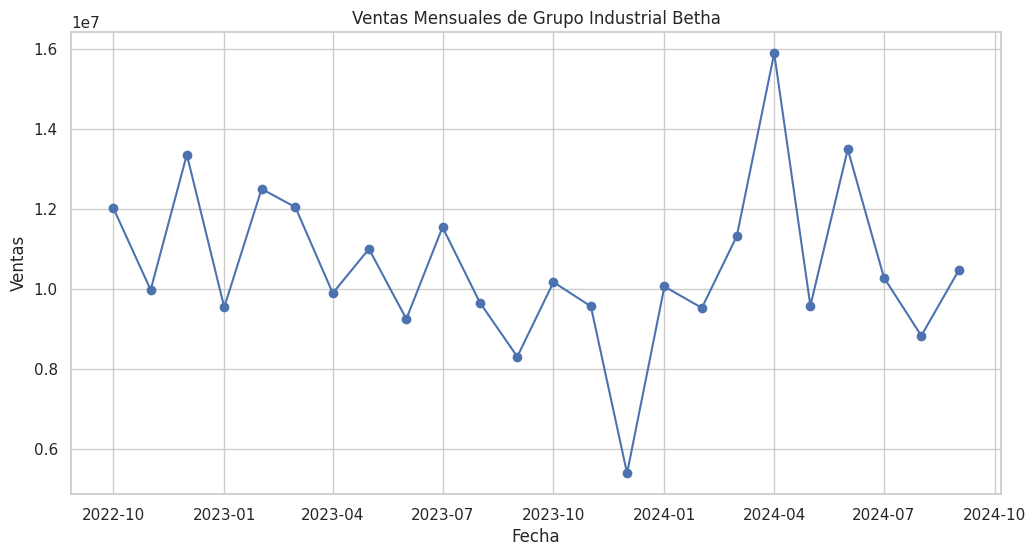

In [366]:
plt.figure(figsize=(12,6))
plt.plot(df_monthly_total.index, df_monthly_total['Total'], marker='o')
plt.title('Ventas Mensuales de Grupo Industrial Betha')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

Defino mis varibles de prueba y de test

In [367]:
# Crear características adicionales (meses y años)
df_monthly_total['month'] = df_monthly_total.index.month  # Usar el índice para obtener los meses
df_monthly_total['year'] = df_monthly_total.index.year    # Usar el índice para obtener los años

# Definir la proporción de entrenamiento (80%)
train_size = int(len(df_monthly_total) * 0.8)

# Dividir los datos en entrenamiento y prueba
X = df_monthly_total[['month', 'year']]
y = df_monthly_total['Total']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Opcional: puedes verificar los tamaños de los conjuntos de datos
print(f"Entrenamiento: {len(X_train)}, Prueba: {len(X_test)}")

Entrenamiento: 19, Prueba: 5


## PROPHET

In [368]:
# PROPHET
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# Preparar los datos para Prophet
train_data = pd.DataFrame({'ds': X_train.index, 'y': y_train})
test_data = pd.DataFrame({'ds': X_test.index, 'y': y_test})

# Entrenar el modelo Prophet
model_prophet = Prophet()
model_prophet.fit(train_data)

# Hacer predicciones con Prophet
future = pd.DataFrame({'ds': X_test.index})
gibsa_prophet = model_prophet.predict(future)

# Calcular el RMSE para Prophet
rmse_prophet = mean_squared_error(y_test, gibsa_prophet['yhat'], squared=False)
print(f'RMSE Prophet: {rmse_prophet:.2f}')

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 14.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpi_ktg4o6/znpvckw2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpi_ktg4o6/uf9jbzrp.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13976', 'data', 'file=/tmp/tmpi_ktg4o6/znpvckw2.json', 'init=/tmp/tmpi_ktg4o6/uf9jbzrp.json', 'output', 'file=/tmp/tmpi_ktg4o6/prophet_modelyevqrj3g/prophet_model-20241126220022.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
22:00:22 - cmdstanpy - INFO - Chain [1] start processing
I

RMSE Prophet: 1669043.04


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [369]:
gibsa = model_prophet.predict(test_data)
gibsa

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-05-01,1.008154e+07,7.396578e+06,1.275919e+07,1.008154e+07,1.008154e+07,0.0,0.0,0.0,0.0,0.0,0.0,1.008154e+07
1,2024-06-01,1.003051e+07,7.491718e+06,1.282302e+07,1.003051e+07,1.003051e+07,0.0,0.0,0.0,0.0,0.0,0.0,1.003051e+07
2,2024-07-01,9.981120e+06,7.464598e+06,1.276754e+07,9.981120e+06,9.981120e+06,0.0,0.0,0.0,0.0,0.0,0.0,9.981120e+06
3,2024-08-01,9.930085e+06,7.172994e+06,1.266773e+07,9.930085e+06,9.930085e+06,0.0,0.0,0.0,0.0,0.0,0.0,9.930085e+06
4,2024-09-01,9.879050e+06,7.125971e+06,1.259699e+07,9.879050e+06,9.879050e+06,0.0,0.0,0.0,0.0,0.0,0.0,9.879050e+06


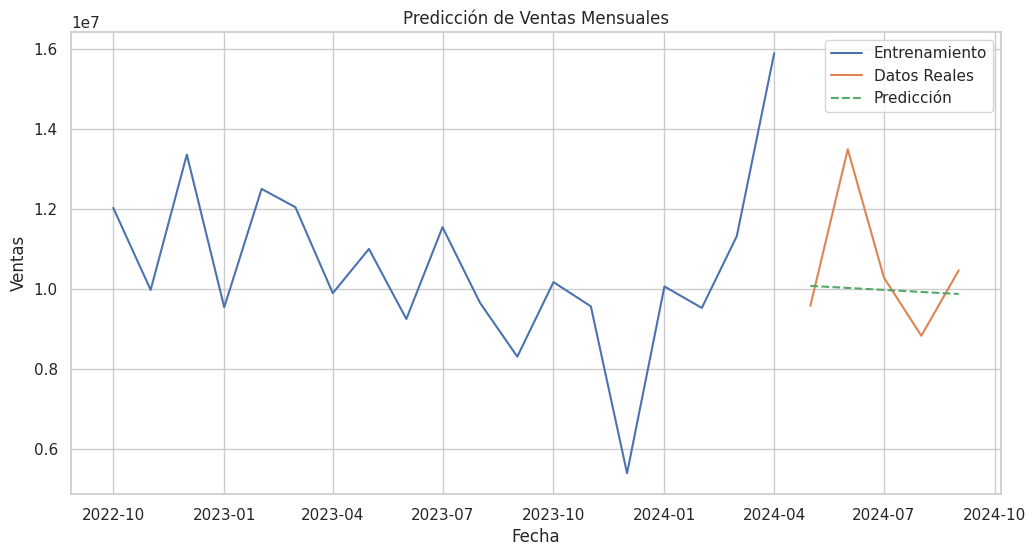

In [370]:
#Se analiza visualmente cómo queda la predicción sobre los datos reales
plt.figure(figsize=(12,6))
plt.plot(train_data.index, train_data['y'], label='Entrenamiento')
plt.plot(test_data.index, test_data['y'], label='Datos Reales')
plt.plot(test_data.index, gibsa['yhat'], label='Predicción', linestyle='--')
plt.title('Predicción de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

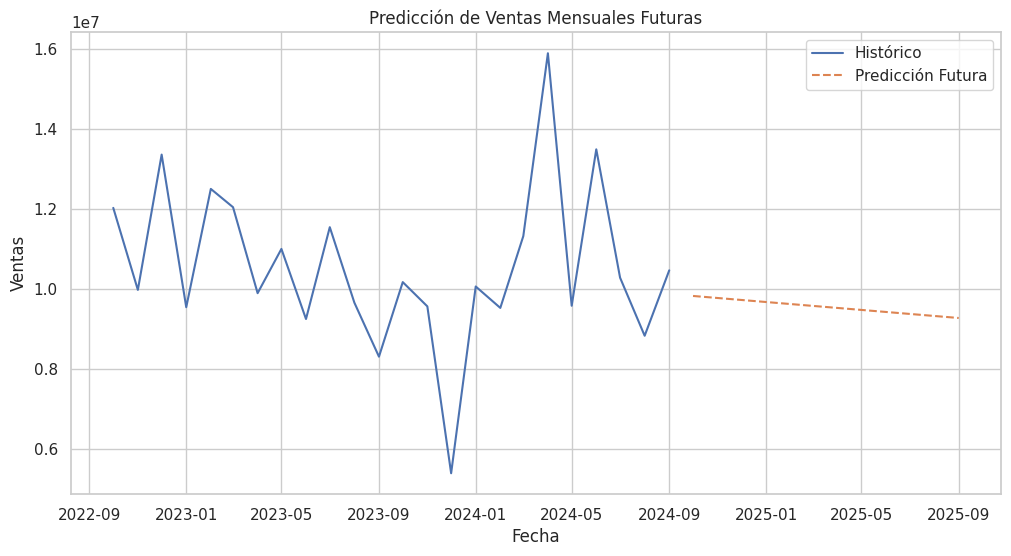

In [371]:
future_periods = 12
last_date = df_monthly_total.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_periods, freq='MS')

future_df = pd.DataFrame({'ds': future_dates})  # Prophet requires a 'ds' column for dates
future_forecast = model_prophet.predict(future_df)

plt.figure(figsize=(12,6))
plt.plot(df_monthly_total.index, df_monthly_total['Total'], label='Histórico')
plt.plot(future_dates, future_forecast['yhat'], label='Predicción Futura', linestyle='--')
plt.title('Predicción de Ventas Mensuales Futuras')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()


## ARIMA

In [372]:
!pip install pmdarima

In [373]:
# pmdarima (Auto ARIMA)
import pmdarima as pm

# Ajustar auto_arima
model_arima = pm.auto_arima(y_train, seasonal=False, stepwise=True)

# Hacer predicciones con auto_arima
n_steps = len(X_test)
gibsa_arima = model_arima.predict(n_periods=n_steps)

# Calcular el RMSE para Auto ARIMA
rmse_arima = mean_squared_error(y_test, gibsa_arima, squared=False)
print(f'RMSE Auto ARIMA: {rmse_arima:.2f}')

RMSE Auto ARIMA: 1591538.73


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [374]:
eval_gibsa_arima = model_arima.predict(n_periods=len(test_data))
eval_gibsa_arima.index.inferred_freq

'MS'

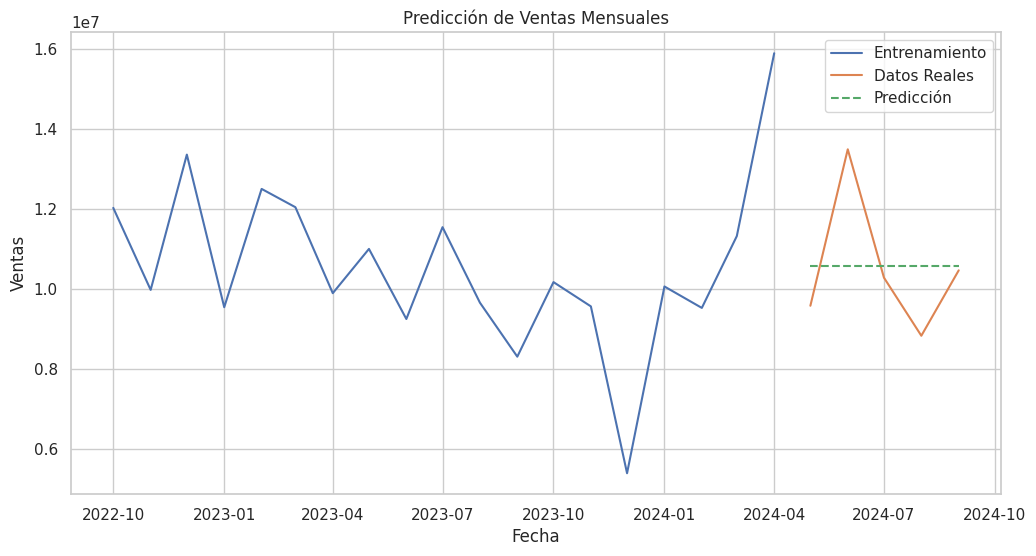

In [375]:
#Analizar que tan acertada es la predicción con los datos reales
plt.figure(figsize=(12,6))
plt.plot(train_data.index, train_data['y'], label='Entrenamiento')
plt.plot(test_data.index, test_data['y'], label='Datos Reales')
plt.plot(test_data.index, eval_gibsa_arima, label='Predicción', linestyle='--') # Change here
plt.title('Predicción de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

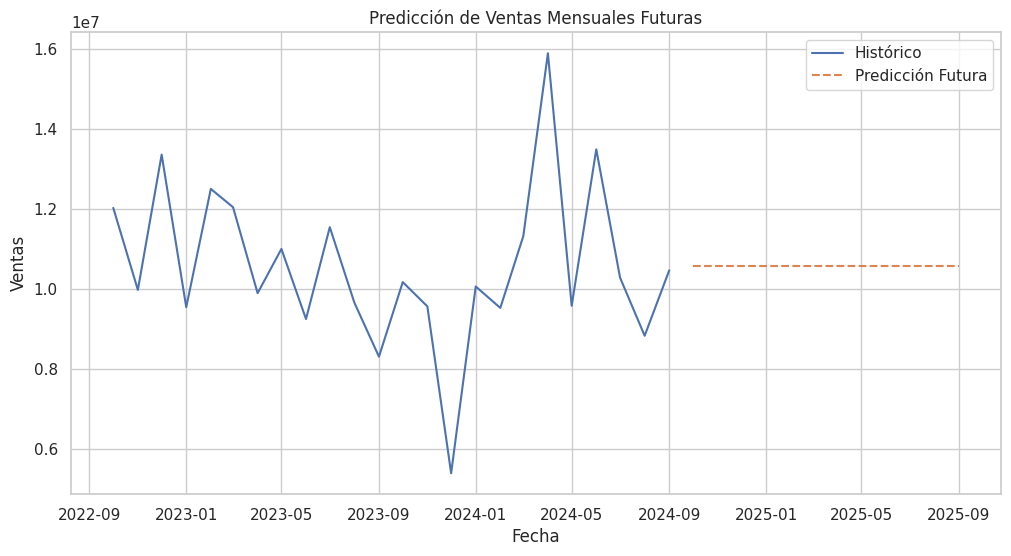

In [376]:
#Predecir a un año
future_periods = 12
last_date = df_monthly_total.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_periods, freq='MS')

# ARIMA future predictions
future_gibsa_arima = model_arima.predict(n_periods=future_periods)

plt.figure(figsize=(12,6))
plt.plot(df_monthly_total.index, df_monthly_total['Total'], label='Histórico')
plt.plot(future_dates, future_gibsa_arima, label='Predicción Futura', linestyle='--') # Updated
plt.title('Predicción de Ventas Mensuales Futuras')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

## REGRESION LINEAL

In [377]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt

# Crear variables dummies para la columna 'month'
X = pd.get_dummies(df_monthly_total[['month', 'year']], columns=['month'], drop_first=True)

# Dividir los datos en entrenamiento y prueba (usando las nuevas variables dummies)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ajustar un modelo de regresión lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Hacer predicciones
predictions_lr = model_lr.predict(X_test)

# Calcular RMSE para la regresión lineal
rmse_lr = sqrt(mean_squared_error(y_test, predictions_lr))
print(f'RMSE for Linear Regression: {rmse_lr}')

RMSE for Linear Regression: 4737780.416927455


In [378]:
gibsa_ML = model_lr.predict(X_test)
gibsa_ML

array([15228997.72428608, 10779498.50571489, 11905427.84428596,
        8170033.81571484, 12199916.67428637])

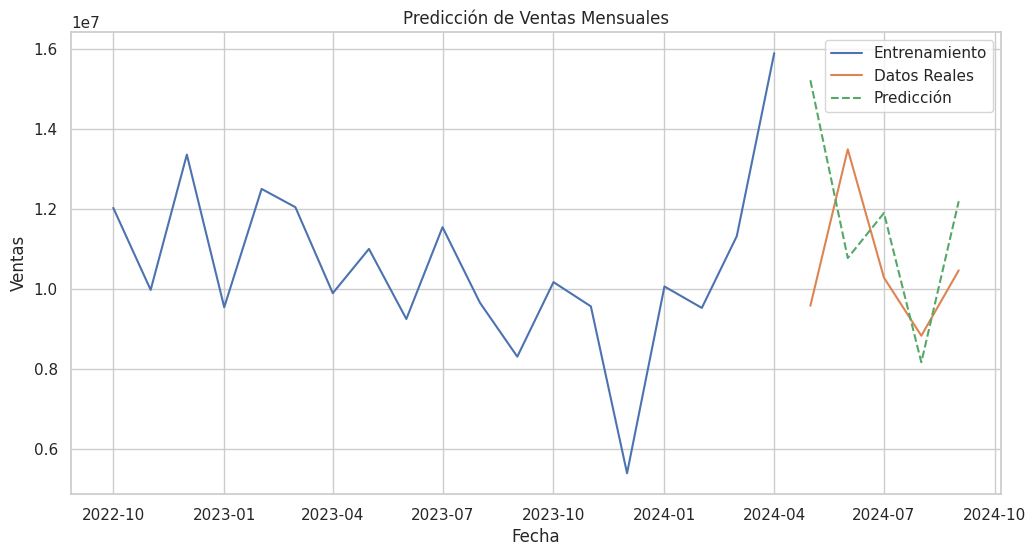

In [379]:
plt.figure(figsize=(12,6))
plt.plot(train_data.index, train_data['y'], label='Entrenamiento')
plt.plot(test_data.index, test_data['y'], label='Datos Reales')
plt.plot(test_data.index, gibsa_ML, label='Predicción', linestyle='--') # Change here
plt.title('Predicción de Ventas Mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

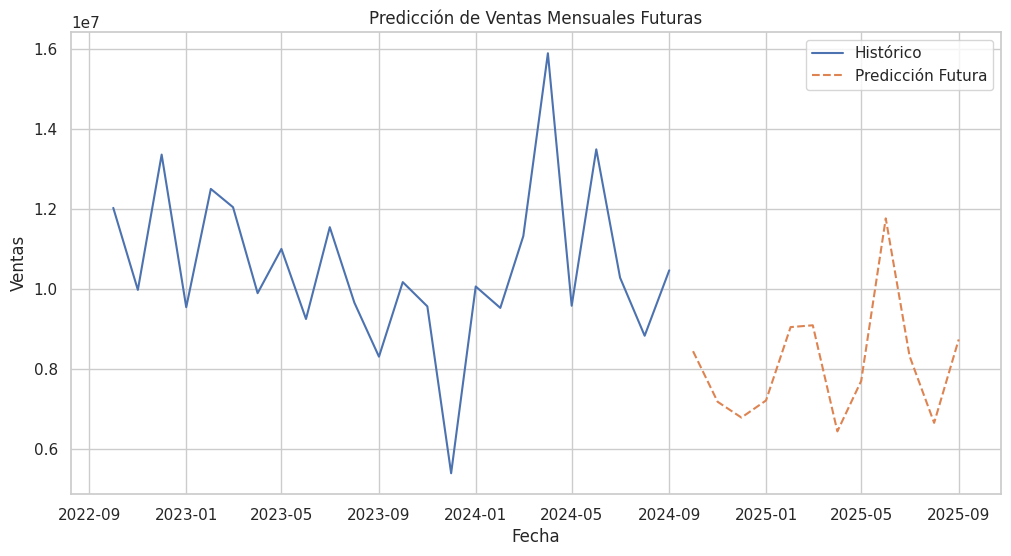

In [380]:
future_periods = 12
last_date = df_monthly_total.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_periods, freq='MS')

# Linear Regression future predictions
future_df_lr = pd.DataFrame({'month': future_dates.month, 'year': future_dates.year}, index=future_dates)

# Get dummies for the future dataframe, keeping the same columns as the training data
future_df_lr = pd.get_dummies(future_df_lr, columns=['month'], drop_first=True)

# Reindex to include all dummy columns (even if some months are missing in future data)
future_df_lr = future_df_lr.reindex(columns=X_train.columns, fill_value=0)


future_forecast_lr = model_lr.predict(future_df_lr)

plt.figure(figsize=(12,6))
plt.plot(df_monthly_total.index, df_monthly_total['Total'], label='Histórico')
plt.plot(future_dates, future_forecast_lr, label='Predicción Futura', linestyle='--') # Updated
plt.title('Predicción de Ventas Mensuales Futuras')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

## Conclusión - Series de Tiempo

Se utilizó Arima. Al no haber una tendencia clara al ser muy variables los datos, la predicción resultó ser plana.
Sugerencias
* Revisar Componentes Estacionales y Ciclos
* Evaluar datos como las campañas de marketing, capacitaciones del personal, condiciones laborales, clima laboral. Evaluar cualquier factor interno que pudiera perjudicar las ventas

# SEM

In [381]:
#Definimos nuestras variables,convertimos nuestros datos, los juntamos y limpiamos
df_sem = df_model
categorical_features = ['Region_MXN', 'GIRO']
numerical_features = ['Edad_Empresa', 'LTV_24']

data_encoded = pd.get_dummies(df_sem[['Cliente']+categorical_features],
                              columns=categorical_features,
                              drop_first=False)

df_data_with_encoded = df_sem[['Cliente']+numerical_features].merge(
    data_encoded, on='Cliente')

df_data_with_encoded = df_data_with_encoded.astype({
    col: 'int' for col in df_data_with_encoded.select_dtypes('bool').columns})

df_data_with_encoded.columns = [col.replace(' ', '') for col in df_data_with_encoded.columns]

df_data_with_encoded.head()

,Cliente,Edad_Empresa,LTV_24,Region_MXN_Centro,Region_MXN_Este,Region_MXN_Foráneo,Region_MXN_Norte,Region_MXN_Oeste,Region_MXN_Sur,GIRO_BIMBO,GIRO_COBERTURADECHOCOLATE,GIRO_MANTEQUILLAS,GIRO_MOSTRADOR,GIRO_PANADERIA,GIRO_SABORIZANTES
0,41085,7,33199.00,1,0,0,0,0,0,0,0,0,0,1,0
1,41138,1,7698080.34,0,0,0,0,1,0,0,0,0,1,0,0
2,40809,7,9805358.50,0,0,0,0,1,0,0,0,0,1,0,0
3,41147,7,35503.00,0,0,0,0,1,0,0,0,0,1,0,0
4,40770,7,3595185.00,0,0,0,0,1,0,0,0,0,1,0,0


In [382]:
columnas = df_data_with_encoded.columns
resultado = ' + '.join(columnas)
print(resultado)

Cliente + Edad_Empresa + LTV_24 + Region_MXN_Centro + Region_MXN_Este + Region_MXN_Foráneo + Region_MXN_Norte + Region_MXN_Oeste + Region_MXN_Sur + GIRO_BIMBO + GIRO_COBERTURADECHOCOLATE + GIRO_MANTEQUILLAS + GIRO_MOSTRADOR + GIRO_PANADERIA + GIRO_SABORIZANTES


In [383]:
!pip install semopy

In [384]:
from semopy import Model, Optimizer

#Tenemos que quitar uno por uno cada valor del p value >0.05
# Definir el modelo SEM usando la notación estándar de SEM
model_desc = """
# Latent Variables
Expectativa_baja=~ Edad_Empresa + Region_MXN_Norte + Region_MXN_Oeste + GIRO_BIMBO + GIRO_MOSTRADOR
"""

In [385]:
mod = Model(model_desc)    #Creas el modelo en base a la descripción dada
res_opt = mod.fit(df_data_with_encoded)    #Alimentas al modelo con tus datos
estimates = mod.inspect()  #Corres el modelo

# Imprimir los resultados del ajuste del modelo
print(estimates)
#A mayor edad de la empresa mayor expectativa tiene la empresa de ti

                lval  op              rval   Estimate  Std. Err    z-value  \
0       Edad_Empresa   ~  Expectativa_baja   1.000000         -          -   
1   Region_MXN_Norte   ~  Expectativa_baja  -0.654411  0.312141  -2.096526   
2   Region_MXN_Oeste   ~  Expectativa_baja   0.394713  0.194525   2.029115   
3         GIRO_BIMBO   ~  Expectativa_baja  -0.650458   0.31052   -2.09474   
4     GIRO_MOSTRADOR   ~  Expectativa_baja   0.374852  0.185807   2.017425   
5   Expectativa_baja  ~~  Expectativa_baja   0.314917  0.300491   1.048006   
6       Edad_Empresa  ~~      Edad_Empresa  16.104490  1.440574  11.179217   
7         GIRO_BIMBO  ~~        GIRO_BIMBO   0.023952  0.008759   2.734409   
8     GIRO_MOSTRADOR  ~~    GIRO_MOSTRADOR   0.200974  0.018389  10.929246   
9   Region_MXN_Norte  ~~  Region_MXN_Norte   0.040746  0.009349   4.358542   
10  Region_MXN_Oeste  ~~  Region_MXN_Oeste   0.191417   0.01759  10.882374   

     p-value  
0          -  
1   0.036036  
2   0.042447  
3  

In [386]:
#creamos el data frame organizando los valores
pd.DataFrame(estimates)[['lval','Estimate','p-value']].iloc[:5]

,lval,Estimate,p-value
0,Edad_Empresa,1.000000,-
1,Region_MXN_Norte,-0.654411,0.036036
2,Region_MXN_Oeste,0.394713,0.042447
3,GIRO_BIMBO,-0.650458,0.036194
4,GIRO_MOSTRADOR,0.374852,0.043651


## Análisis SEM

* Mientras más edad tenga la empresa del cliente, menos expectativa
* Si el cliente es del norte mas expectativa
* Si el cliente es del oeste menos expectativa
* Si el cliente es Bimbo más expectativa
* Si la venta es de mostrador menos expectativa

En este caso, los Estimates negativos son aquellos a los que se les ve mayor expectativa y los que tienen Estimates positivos son aquellos que tienen menores expectativas.

In [387]:
# Cargar factores estimados (cargas factoriales)
# Estos valores deben obtenerse del ajuste del modelo SEM
expectativa_factors = {  # Reemplaza con los valores reales del modelo
    'Edad_Empresa': 1.0,   # Factor de carga para Edad_Empresa
    'Region_MXN_Norte': -0.654411, # Factor de carga para Region_MXN_Norte
    'Region_MXN_Oeste': 0.394713, # Factor de carga para Region_MXN_Oeste
    'GIRO_BIMBO': -0.650458,    # Factor de carga para GIRO_BIMBO
    'GIRO_MOSTRADOR': 0.374852  # Factor de carga para GIRO_MOSTRADOR
}

# Función para calcular el valor de la variable latente
def calculate_latent_values(df):
    df_data_with_encoded['Expectativa baja'] = (
        df_data_with_encoded['Edad_Empresa'] * expectativa_factors['Edad_Empresa'] +
        df_data_with_encoded['Region_MXN_Norte'] * expectativa_factors['Region_MXN_Norte'] +
        df_data_with_encoded['Region_MXN_Oeste'] * expectativa_factors['Region_MXN_Oeste'] +
        df_data_with_encoded['GIRO_BIMBO'] * expectativa_factors['GIRO_BIMBO'] +
        df_data_with_encoded['GIRO_MOSTRADOR'] * expectativa_factors['GIRO_MOSTRADOR']
    )

    return df_data_with_encoded['Expectativa baja']

# Calcular valores latentes en el dataset
latent_values = calculate_latent_values(df_data_with_encoded)

# Mostrar los primeros valores calculados
print(latent_values.head())

0    7.000000
1    1.769565
2    7.769565
3    7.769565
4    7.769565
Name: Expectativa baja, dtype: float64


In [388]:
df_data_with_encoded.head()

,Cliente,Edad_Empresa,LTV_24,Region_MXN_Centro,Region_MXN_Este,Region_MXN_Foráneo,Region_MXN_Norte,Region_MXN_Oeste,Region_MXN_Sur,GIRO_BIMBO,GIRO_COBERTURADECHOCOLATE,GIRO_MANTEQUILLAS,GIRO_MOSTRADOR,GIRO_PANADERIA,GIRO_SABORIZANTES,Expectativa baja
0,41085,7,33199.00,1,0,0,0,0,0,0,0,0,0,1,0,7.000000
1,41138,1,7698080.34,0,0,0,0,1,0,0,0,0,1,0,0,1.769565
2,40809,7,9805358.50,0,0,0,0,1,0,0,0,0,1,0,0,7.769565
3,41147,7,35503.00,0,0,0,0,1,0,0,0,0,1,0,0,7.769565
4,40770,7,3595185.00,0,0,0,0,1,0,0,0,0,1,0,0,7.769565


In [389]:
from semopy import semplot

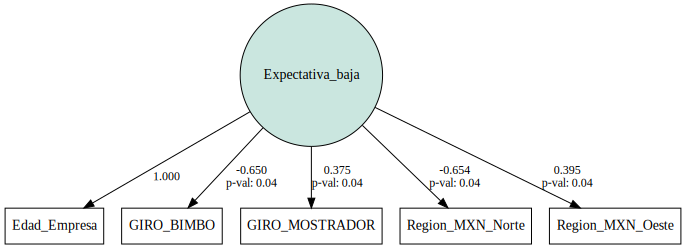

In [390]:
g = semplot(mod, "pd.png")  # Specify the filename directly
g

Grupo Bimbo al ser una empresa muy grande siempre tiene las expectativas muy altas, de igual manera, la mayor parte de los clientes se encuentran ubicados en el Norte del país por lo que si es coherente que también tengan altas expectativas. Parece ser que mientras más edad tenga la empresa del cliente, tienen menores expectativas, así como los clientes que compran a mostrador y aquellos ubicados en el Oeste.

**ACCIONES:**

* Se sugiere darles una mayor atención a las empresas que tienen más edad, ya que, al igual que Grupo Bimbo que es una empresa grande, seguramente aquellas empresas de mayor tamaño también podrían darle un mayor LTV a la empresa.
* Analizar la atención al cliente y el tiempo de entrega a aquellos clientes que compran a mostrador para poder mejorar su expectativa.
* La región Oeste no es el fuerte de la empresa pero de igual manera hay que verificar cuáles son las quejas más recurrentes para poder corregirlas y mejorar su expectativa.

## AB TESTING

In [391]:
#de acuerdo a lo que hemos visto de la empresa hacer el AB testing
#calcular el sample size, propuesta (indicador, que cambiaria)

**AB testing de marketing**

Actualmente se tienen campañas publicitarias en Facebook y Google Ads e incluso se tiene la página web. El problema actual que enfrenta la empresa es que las compras en línea y el alcance que han tenido las publicaciones se ha visto estancada, ya no crece. Sin embargo, revendedores venden exactamente el mismo producto a un precio más elevado y logran tener mayor alcance que la misma empresa. Por esto mismo, se cree que el problema radica en la manera de realizar las campañas publicitarias.

Se propone hacer AB testig para lo siguiente:

* Cambiar la página web para poder analizar si la tasa de conversión de clientes (Muestra B), es mayor que la tasa de conversión que la Muestra A. Nos gustaría pasar del 6% al 7%
  * $H0: CR_B - CR_A ≤ 0.01$
  * $H1: CR_B - CR_A > 0.01$
  
  
* Verificar sí un nuevo diseño en las campañas publicitarias mejora significantemente el valor de las ventas en línea de la muestra A. Pasar de una media de 4,000 a 5,000 y una desviación de 1,000.
  * $H0: μ_B (nuevo) - μ_A (actual) ≤ 5000$
  * $H1: μ_B (nuevo) - μ_A (actual) > 5000$

Con un nivel de confianza del **95%** y un poder estadístico del **80%**.


In [392]:
#Sample size proporción
import math

math.ceil((2*(1.96+0.84)**2*0.06*0.94)/(0.01**2))

8844

In [393]:
#Sample size medias
import math

math.ceil((2*(1.96+0.84)**2*(1000**2))/(1000**2))

16

## AI generativa

#### **1. Sistema de Recomendaciones Personalizado Basado en LTV y Giro del Cliente**

Implementar un sistema de recomendaciones personalizado para los clientes, de esta manera se puede mejorar su experiencia y por ende incrementar tanto las ventas como la retención de clientes.

**Funcionamiento:**
- **Segmentación por LTV:** Identificar a los clientes con mayor LTV permite priorizar recomendaciones que maximicen su experiencia y fidelización. Por ejemplo:
  - **Clientes individuales:** Recomendaciones de productos según sus patrones de compra previos.
  - **Clientes empresariales:** Sugerencias de productos relacionados con su tipo de producción, como aceites específicos para aplicaciones industriales o alimentarias.
  
- **Asesoría para empresas:** Para clientes B2B, como fabricantes o distribuidores, se habilitará una herramienta de consulta automatizada. Este sistema podrá analizar factores como el tamaño de la empresa, su volumen de producción y sus necesidades específicas para recomendar productos adecuados que optimicen su operación.

**Impacto esperado:**
- Mejora en la experiencia del cliente al recibir recomendaciones precisas.
- Incremento del ticket promedio gracias a la oferta de productos relevantes.
- Fortalecimiento de la lealtad al ofrecer soluciones personalizadas.

---

**Implementación:**

**Propuesta:** Integrar un botón en la página web oficial (www.) que permita acceso a un chatbot avanzado. Este chatbot utilizará AI generativa para interactuar con los clientes y brindar recomendaciones personalizadas en tiempo real.

**Funciones clave del chatbot:**
- **Para clientes individuales:** Recomendaciones de compra basadas en sus preferencias históricas y comportamiento actual.
- **Para empresas:** Respuestas a consultas técnicas sobre productos y sugerencias específicas según el tipo de producción (alimenticia, cosmética, industrial, etc.).
- **Asesoría en sostenibilidad:** Recomendaciones sobre productos sostenibles o procesos ecológicos que se alineen con las tendencias de la industria.

**Beneficios adicionales:**
- Disponibilidad 24/7 para atender preguntas o solicitudes.
- Automatización de tareas repetitivas para liberar tiempo del equipo humano.
- Posibilidad de recopilar datos en tiempo real para alimentar estrategias de marketing.

---